In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

In [2]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward, make_parent_and_children_correlated_dog
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory, animate_heatmap_trajectory
from abm.batch_analysis import (
    run_condition_batches,
    summarize_condition_timeseries,
    summarize_mean_reward_last_steps,
    plot_condition_comparison,
    summarize_batch_metrics,
    plot_metric_suite_by_lambda,
 )

sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments

## 1. Asocial individuals, human-like parameters

In [ ]:
rng = np.random.default_rng(42)

grid_size = 20
reward_params = {
    'frequency': 2.5,
    'center': (grid_size // 4, grid_size // 4),
    'correlation': 1
}
params = {
    "n": [30],
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": grid_size * 1.5 / (2*np.pi * reward_params['frequency']),
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'dog',
    "reward_env_params": [reward_params]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=80,
    display_progress=True,
    data_collection_period=1,
    number_processes=None
)

  0%|          | 0/1 [00:00<?, ?it/s]

### A. Plot mean across many iterations

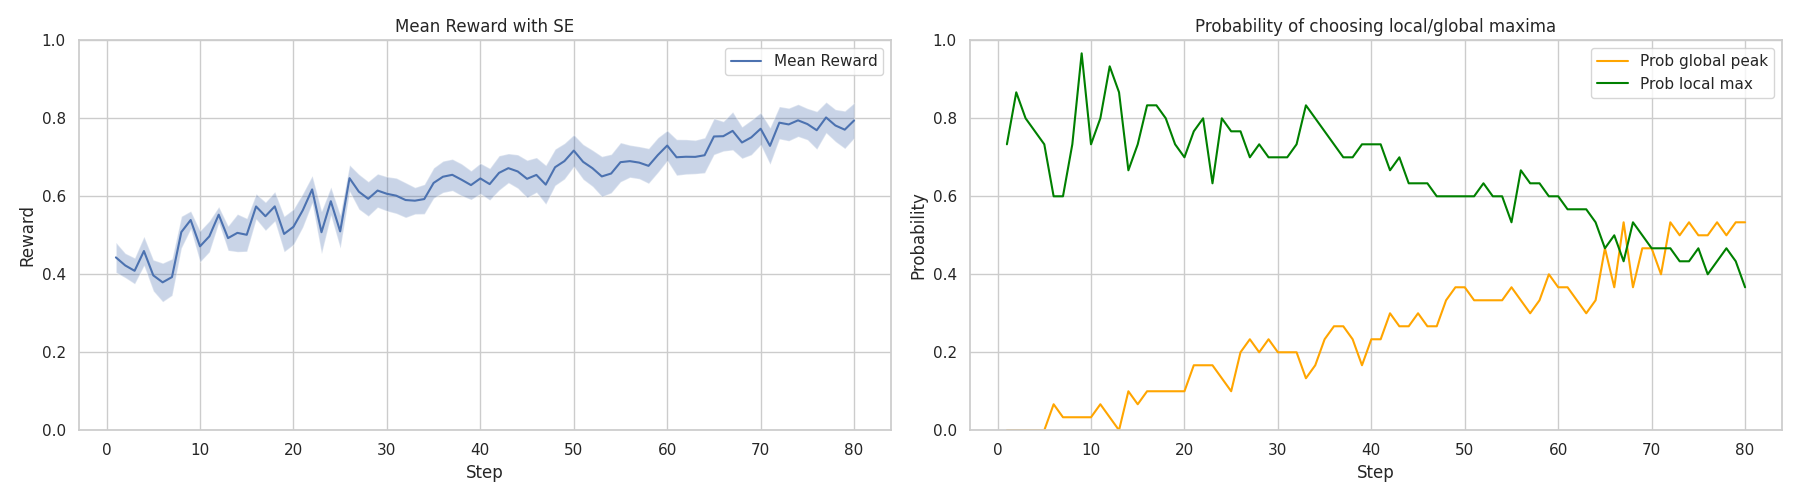

In [ ]:
df_batch = pd.DataFrame(batch_results)

# Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['mean_reward'], label='Mean Reward')
axes[0].fill_between(df_batch['Step'], df_batch['mean_reward'] - df_batch['se_reward'], df_batch['mean_reward'] + df_batch['se_reward'], alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['prob_near_peak'], label='Prob global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['prob_local_max'], label='Prob local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

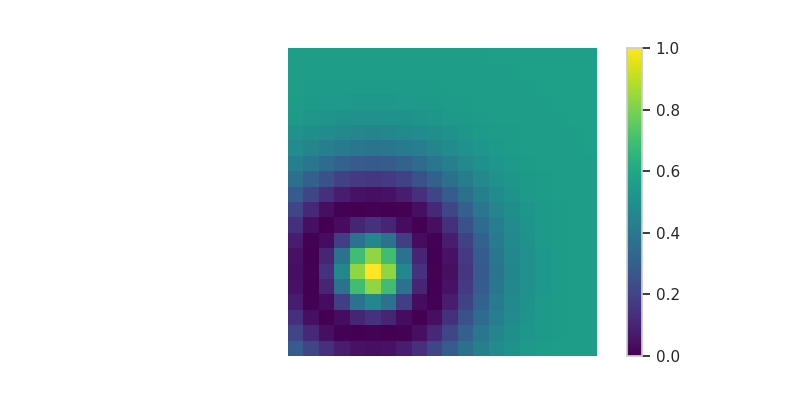

In [ ]:
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_reward_grid(reward)

### B. Plot Individual trajectories

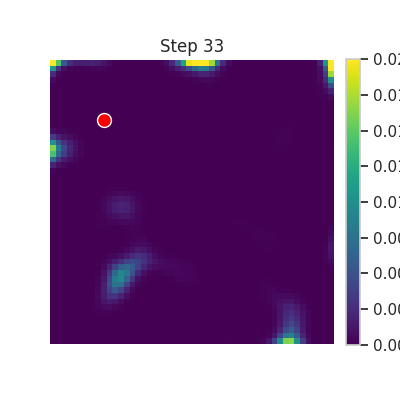

In [ ]:
df_batch = pd.DataFrame(batch_results)

heatmaps = df_batch['policy'].to_numpy()  # shape (60,), each element is a 2D array
fig, ax = plt.subplots(figsize=(4, 4))

vmin = min(h.min() for h in heatmaps)
vmax = min(max(h.max() for h in heatmaps), 0.02)

im = ax.imshow(
    heatmaps[1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
)
ax.scatter(df_batch.loc[0, 'choice'][0], df_batch.loc[0, 'choice'][1], color='red', s=100, edgecolor='white')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def update(frame):
    ax.clear()  # Clear previous scatter points
    # im.set_array(heatmaps[frame+1])  # Update the data
    im = ax.imshow(
        heatmaps[frame+1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
    )
    ax.scatter(df_batch.loc[frame, 'choice'][0], df_batch.loc[frame, 'choice'][1], color='red', s=100, edgecolor='white')
    ax.set_title(f'Step {frame}')
    ax.axis('off')
    return im,

ani = FuncAnimation(fig, update, frames=len(heatmaps)-1, repeat=False)
ani.save('policy_evolution.gif', writer='pillow', fps=1)

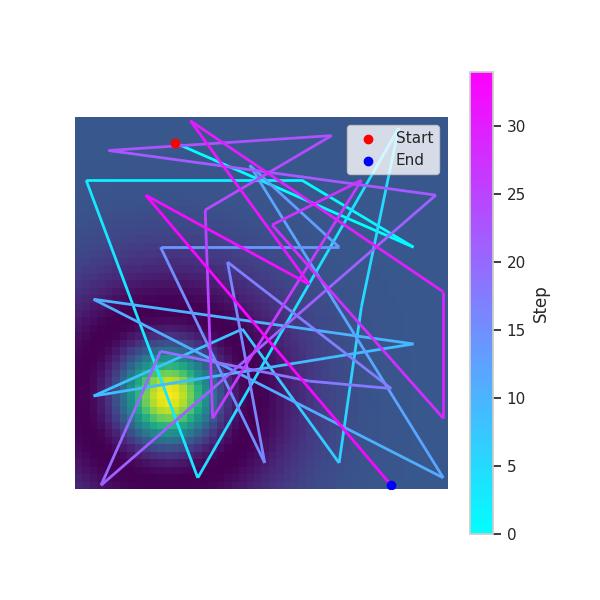

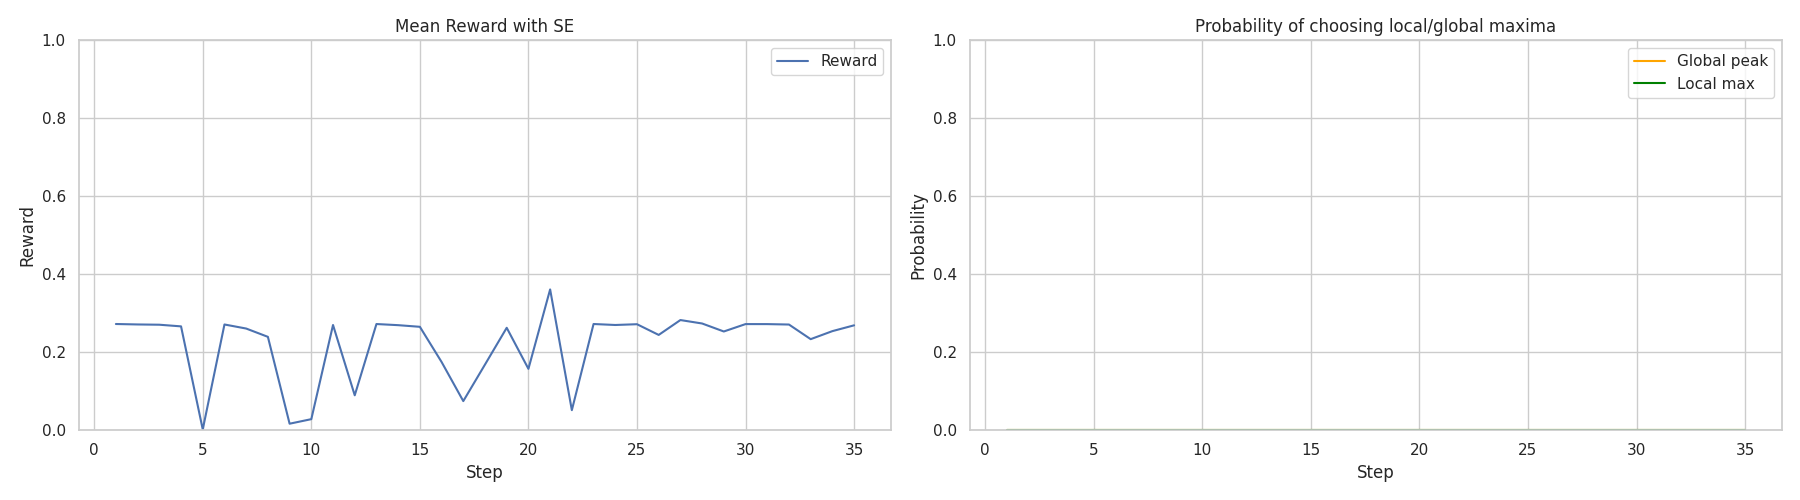

In [ ]:
# 1. Plot most common choice trajectory
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_most_common_choice_trajectory(df_batch, reward, title='', choice_col='choice')

# 2. Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['reward'], label='Reward')
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['near_peak'], label='Global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['local_max'], label='Local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Test Correlated DoG

### 2.a Simulate average behavior

In [3]:
grid_size   = 33
lambda_true = 4.5
# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9
}

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.01,
        "length_scale": lambda_true,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true/2.0,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true/2.0,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.01,
        "length_scale": lambda_true/2.0,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": ["distance_to_global_peak", "distance_to_local_peak", "reward"]
    }
}

In [26]:
n_runs      = 100
max_steps   = 30

batch_results = mesa.batch_run(
    SocialGPModel,
    rng=[None]*n_runs,
    parameters=params['lambda_is_sigma_i_low_random'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/300 [00:00<?, ?it/s]

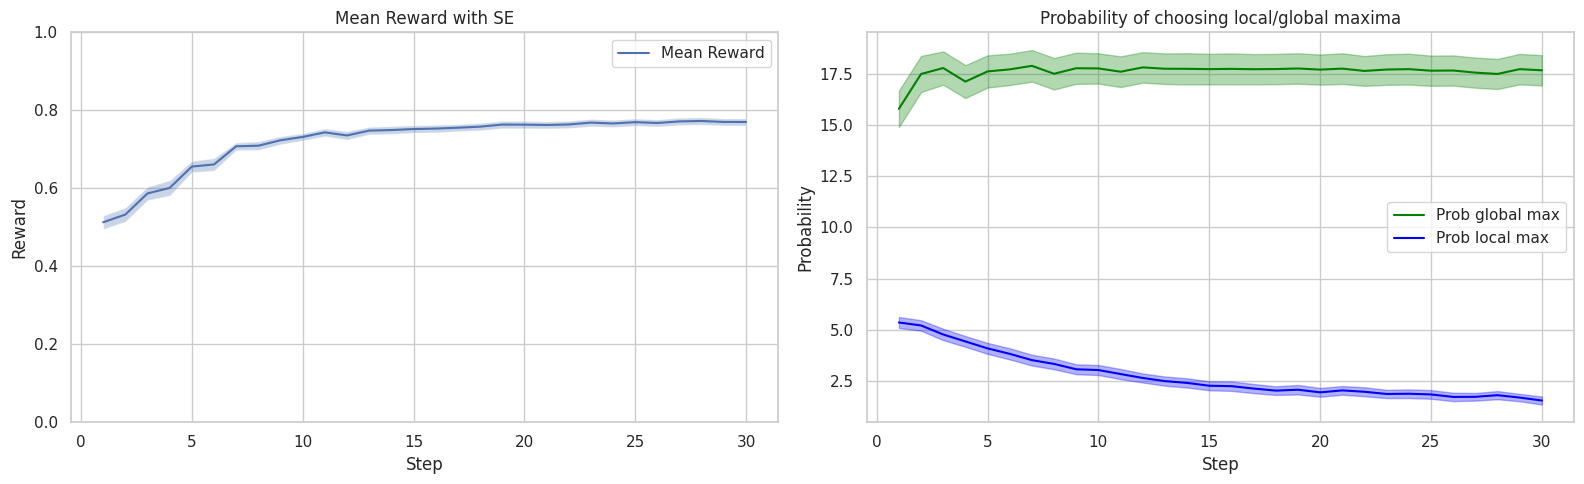

In [31]:
df_batch = pd.DataFrame(batch_results)
df_grouped = df_batch.groupby('Step').agg({
    'reward': ['mean', 'std'],
    'distance_to_global_peak': ['mean', 'std'],
    'distance_to_local_peak': ['mean', 'std'],
    # 'global_max': ['mean', 'std'],
    # 'local_max': ['mean', 'std'],
    # 'no_max': ['mean', 'std']
    }).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['distance_to_global_peak']['mean']
global_max_SE = df_grouped['distance_to_global_peak']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['distance_to_local_peak']['mean']
local_max_SE = df_grouped['distance_to_local_peak']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
# not_any_max_mean = df_grouped['no_max']['mean']
# not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
# axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
# axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
# axes[1].set_ylim(-0.01, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.c Compare all parameter combinations
Run all entries in `params` and compare trajectories across conditions for cumulative reward, mean reward, and max-state probabilities.

In [ ]:
batches = ['naito', 'lambda_is_sigma_i_naito', 'lambda_is_sigma_o_naito']
comparison_parameter_sets = {
    condition_name: {
        **condition_parameters,
        "model_reporters_to_collect": ["mean_reward"],
        "agent_reporters_to_collect": [
            "reward",
            "cumulative_reward",
            "global_max",
            "local_max",
            "no_max",
            "distance_to_global_peak",
            "distance_to_local_peak",
        ],
    }
    for condition_name, condition_parameters in params.items()
    if condition_name in batches
}

n_runs = 10
max_steps = 30
comparison_results = run_condition_batches(
    model_cls=SocialGPModel,
    parameter_sets=comparison_parameter_sets,
    n_runs=n_runs,
    max_steps=max_steps,
    data_collection_period=1,
    number_processes=None,
    display_progress=True,
    rng_values=[None] * n_runs,
 )

comparison_summary = summarize_condition_timeseries(comparison_results)
mean_reward_last_5 = summarize_mean_reward_last_steps(
    comparison_results,
    window_size=5,
    reward_col='reward',
    step_col='Step',
    condition_col='condition',
)

comparison_summary.head(), mean_reward_last_5

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,condition,Step,cumulative_reward,reward,global_max,local_max,no_max
0,lambda_is_sigma_i_naito,5.0,2.528278,0.607655,0.1,0.5,0.4
1,lambda_is_sigma_i_naito,10.0,5.369431,0.537283,0.0,0.1,0.9
2,lambda_is_sigma_i_naito,15.0,8.461542,0.641554,0.0,0.1,0.9
3,lambda_is_sigma_i_naito,20.0,11.346851,0.617270,0.0,0.2,0.8
4,lambda_is_sigma_i_naito,25.0,14.343830,0.601240,0.1,0.0,0.9


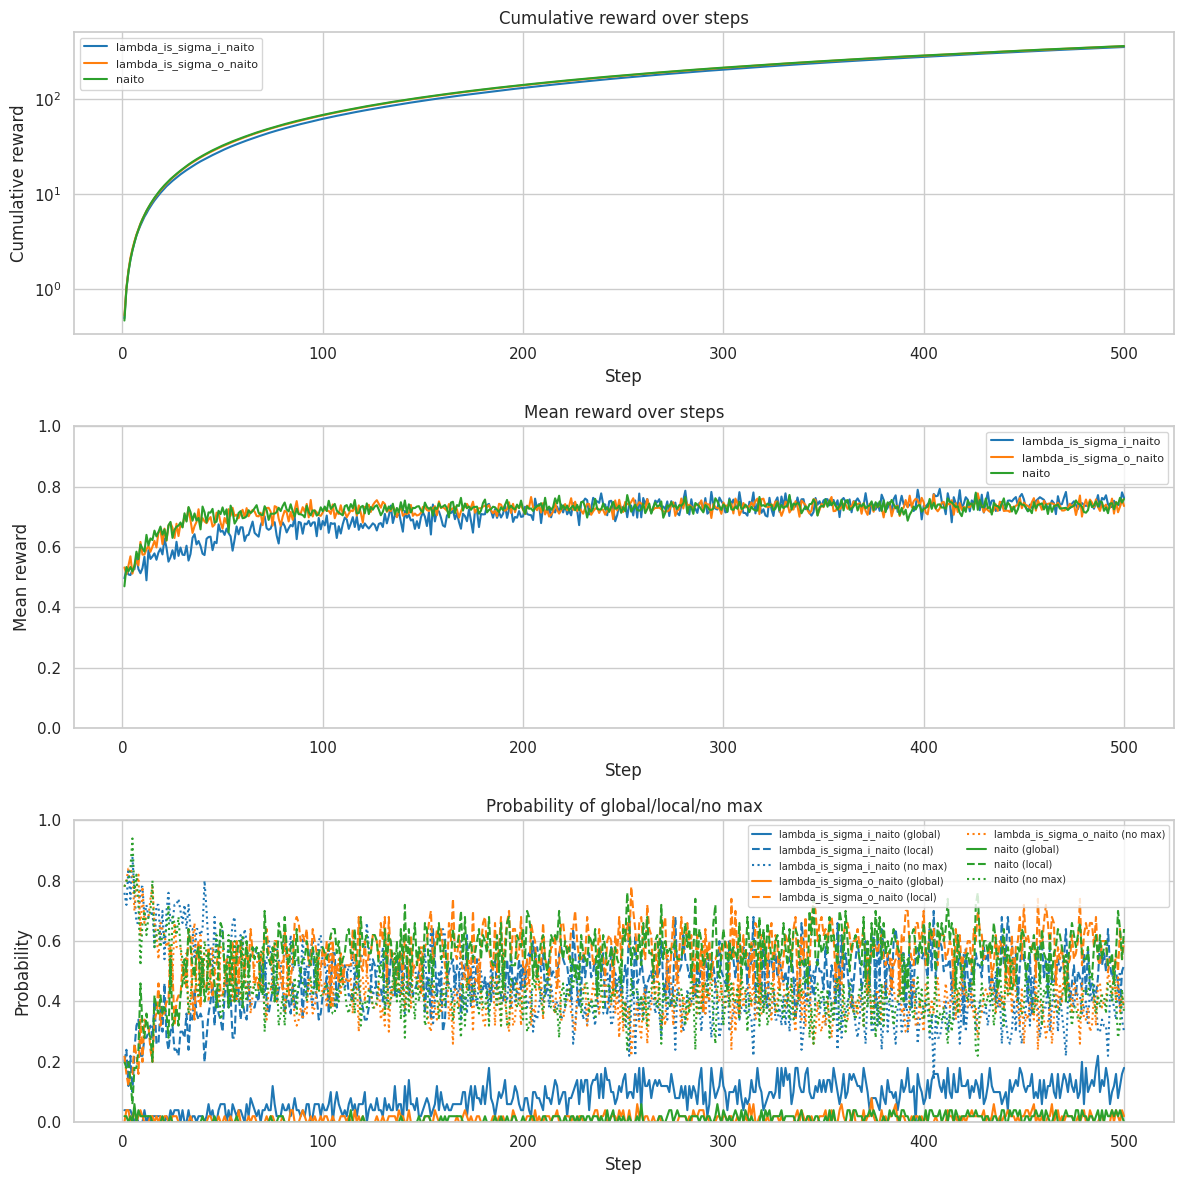

In [22]:
plot_condition_comparison(comparison_summary)
plt.show()

### 2.d Analyze sample individual

In [15]:
seed = 24
rng  = np.random.default_rng(seed)

grid_size   = 33
lambda_true = 4.5
n_runs      = 1
max_steps   = 30
# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9
}

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.19,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_true_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.01,
        "length_scale": lambda_true,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_true_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_inner_naito': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.19,
        "length_scale": lambda_true/2.0,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    }
}

In [16]:
batch_results = mesa.batch_run(
    SocialGPModel,
    rng=[rng]*n_runs,
    parameters=params['lambda_inner_naito'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

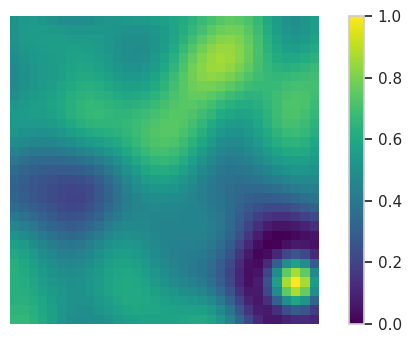

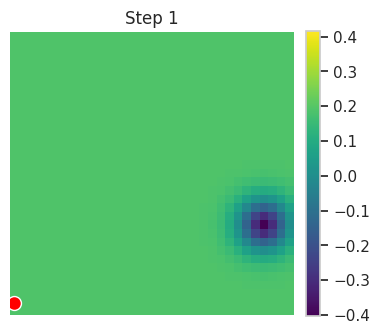

In [17]:
rng = np.random.default_rng(seed)
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9,
    'n_children': 1
}

_, reward, _ = make_parent_and_children_correlated_dog(
    rng=rng,
    grid_size=grid_size,
    **reward_params
)
plot_reward_grid(reward[0])
plt.show()

df_batch = pd.DataFrame(batch_results)
ani, fig, ax = animate_heatmap_trajectory(
    df_batch,
    heatmap_col='value',
    choice_col='choice',
    save_path='policy_evolution.gif',
    fps=3,
    start_idx=1,
    repeat=False,
    title_prefix='Step',
)

## 3. Sweep $\beta$ and $\tau$ parameters
For small batches/few parameter configurations, can execute the cell below (may take about an hour).

For larger parameter sweeps, use ```run_parameter_sweep.sh``` to run a slurm batch. Usage:
- in home/\<user\>/Spatial-MAB-taboo: ``` sbatch --export=ALL,OUTPUT_DIR=/scratch/<user>/results run_parameter_sweep.sh``` 
- By default, results will be saved to scratch/\<user\>/parameter_sweep.csv

In [ ]:
grid_size = 33
lambda_true = 4.5
n_runs    = 50
max_steps = 300

# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated DoG environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9,
}

params = {
    "n": 1,
    "grid_size": grid_size,
    "beta": np.arange(0, 0.51, 0.025),
    "length_scale": lambda_true * np.array([0.5, 1.0, 2.0]),
    "tau": np.array([0.005]) + np.arange(0.01, 0.11, 0.01),
    "alpha": 0,
    "reward_env_type": 'corr_dog',
    "reward_env_params": [reward_params],
    "collect_agent_reporters": True,
    "model_reporters_to_collect": [["mean_cumulative_reward"]],
    "agent_reporters_to_collect": [["distance_to_global_peak", "distance_to_local_peak", "reward"]],
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=-1,
    number_processes=None,
    rng=[None] * n_runs,
 )

df_batch = pd.DataFrame(batch_results)
df_batch.to_csv('parameter_sweep_corr_dog.csv', index=False)

In [10]:
# join all csv files in /scratch/results/parameter_sweep_*.csv into a single dataframe and save as parameter_sweep.csv
import glob
csv_files = glob.glob('/scratch/parra/results/parameter_sweep_*.csv')
df_list = [pd.read_csv(file) for file in csv_files]
df_combined = pd.concat(df_list, ignore_index=True)
df_combined.to_csv('/scratch/parra/parameter_sweep.csv', index=False)

required_columns = [
    'beta',
    'length_scale',
    'tau',
    'mean_cumulative_reward',
    'distance_to_global_peak', 
    'distance_to_local_peak', 
    'reward',
    'global_max',
    'local_max',
]
missing_columns = [column for column in required_columns if column not in df_combined.columns]
if missing_columns:
    raise KeyError(f"Missing columns in batch results: {missing_columns}")

df_combined[required_columns].head()

,beta,length_scale,tau,mean_cumulative_reward,distance_to_global_peak,distance_to_local_peak,reward,global_max,local_max
0,0.0,4.5,0.055,399.586603,12.035669,1.000000,0.837119,0,1
1,0.0,4.5,0.055,376.587027,29.764760,2.236068,0.791844,0,1
2,0.0,4.5,0.055,398.698694,34.715120,4.123106,0.689014,0,0
3,0.0,4.5,0.055,355.820007,18.396078,2.236068,0.739143,0,1
4,0.0,4.5,0.055,390.404621,18.000000,1.000000,0.868234,0,1


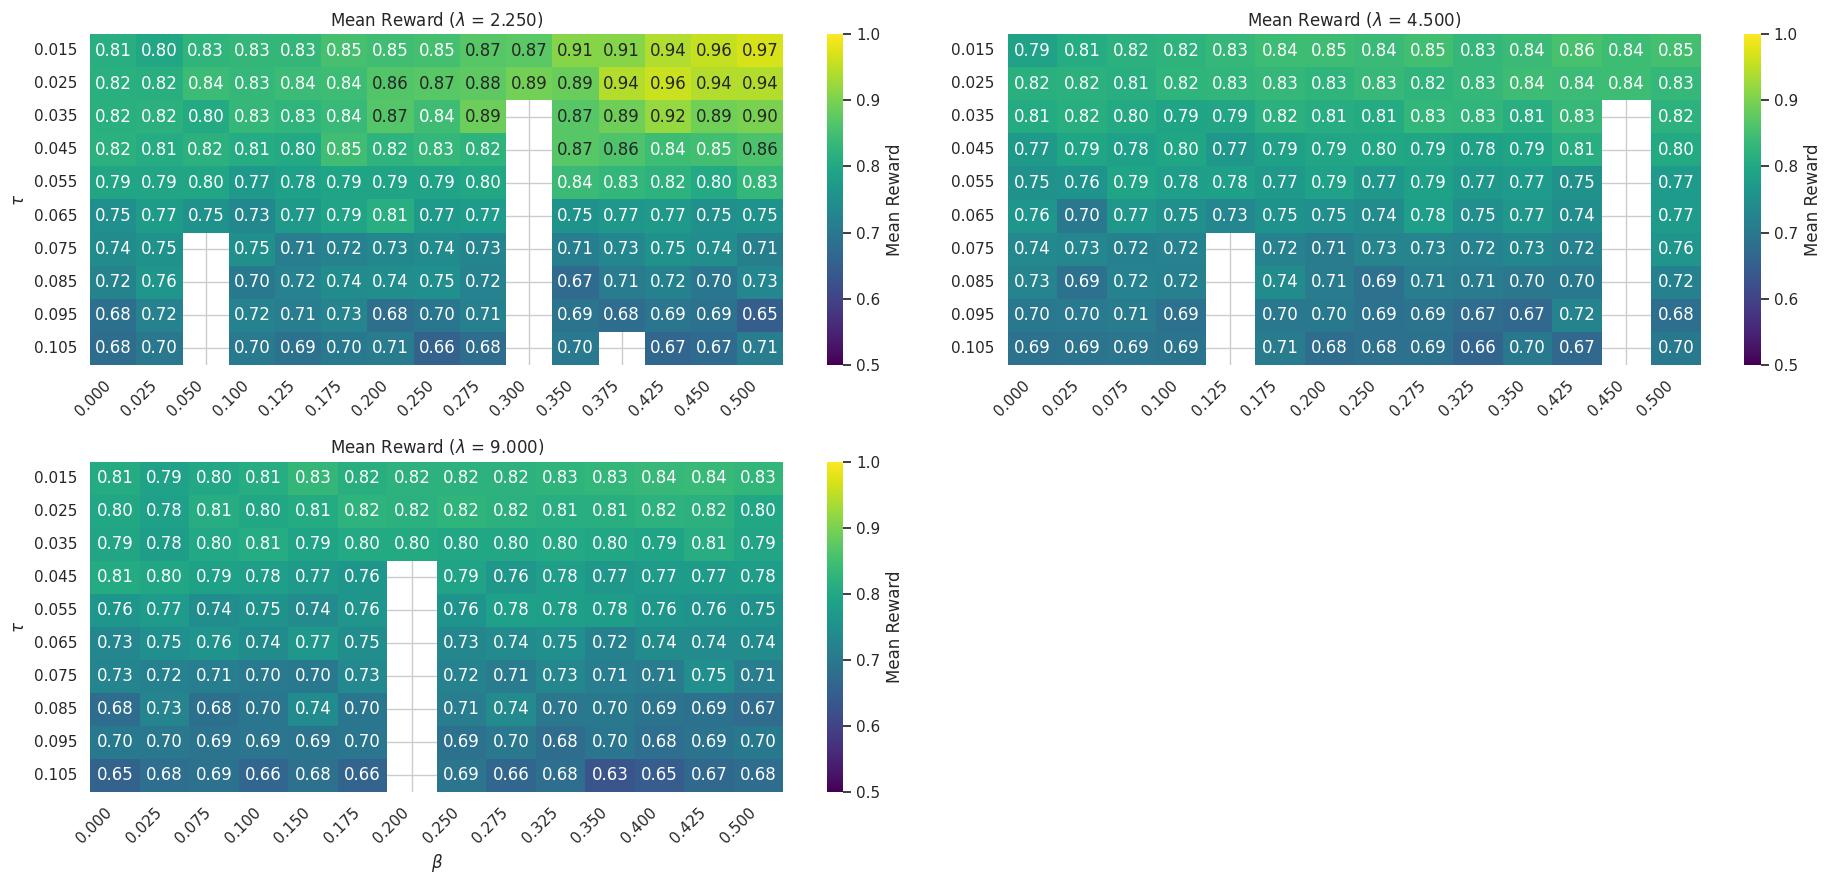

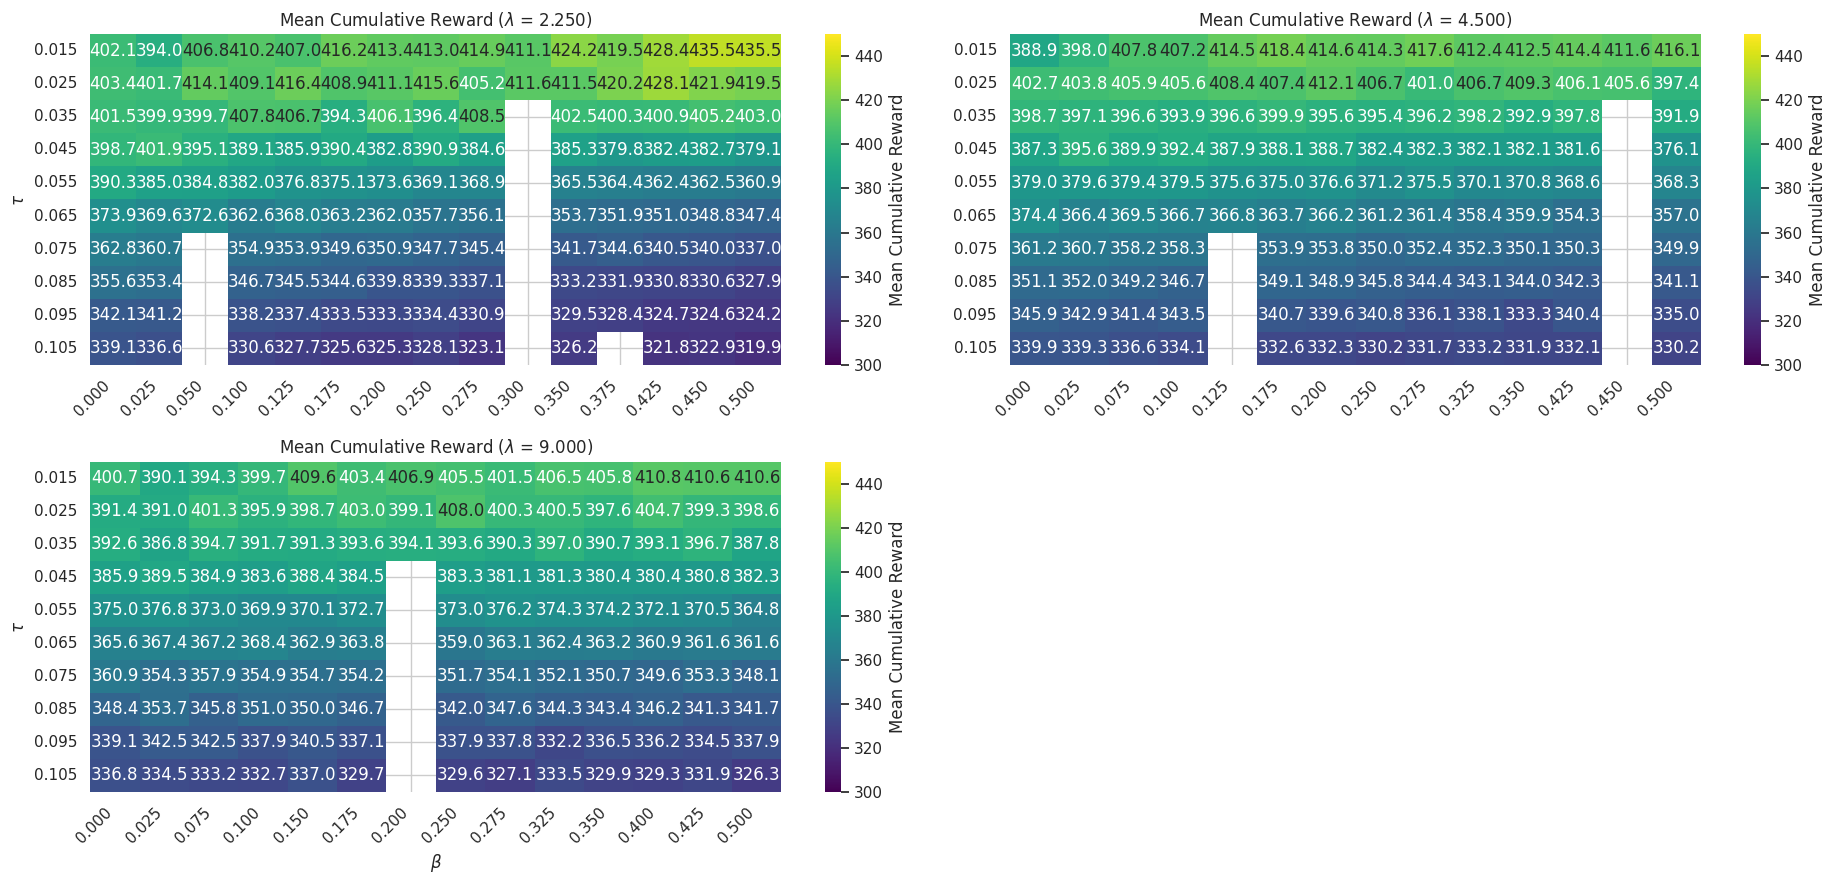

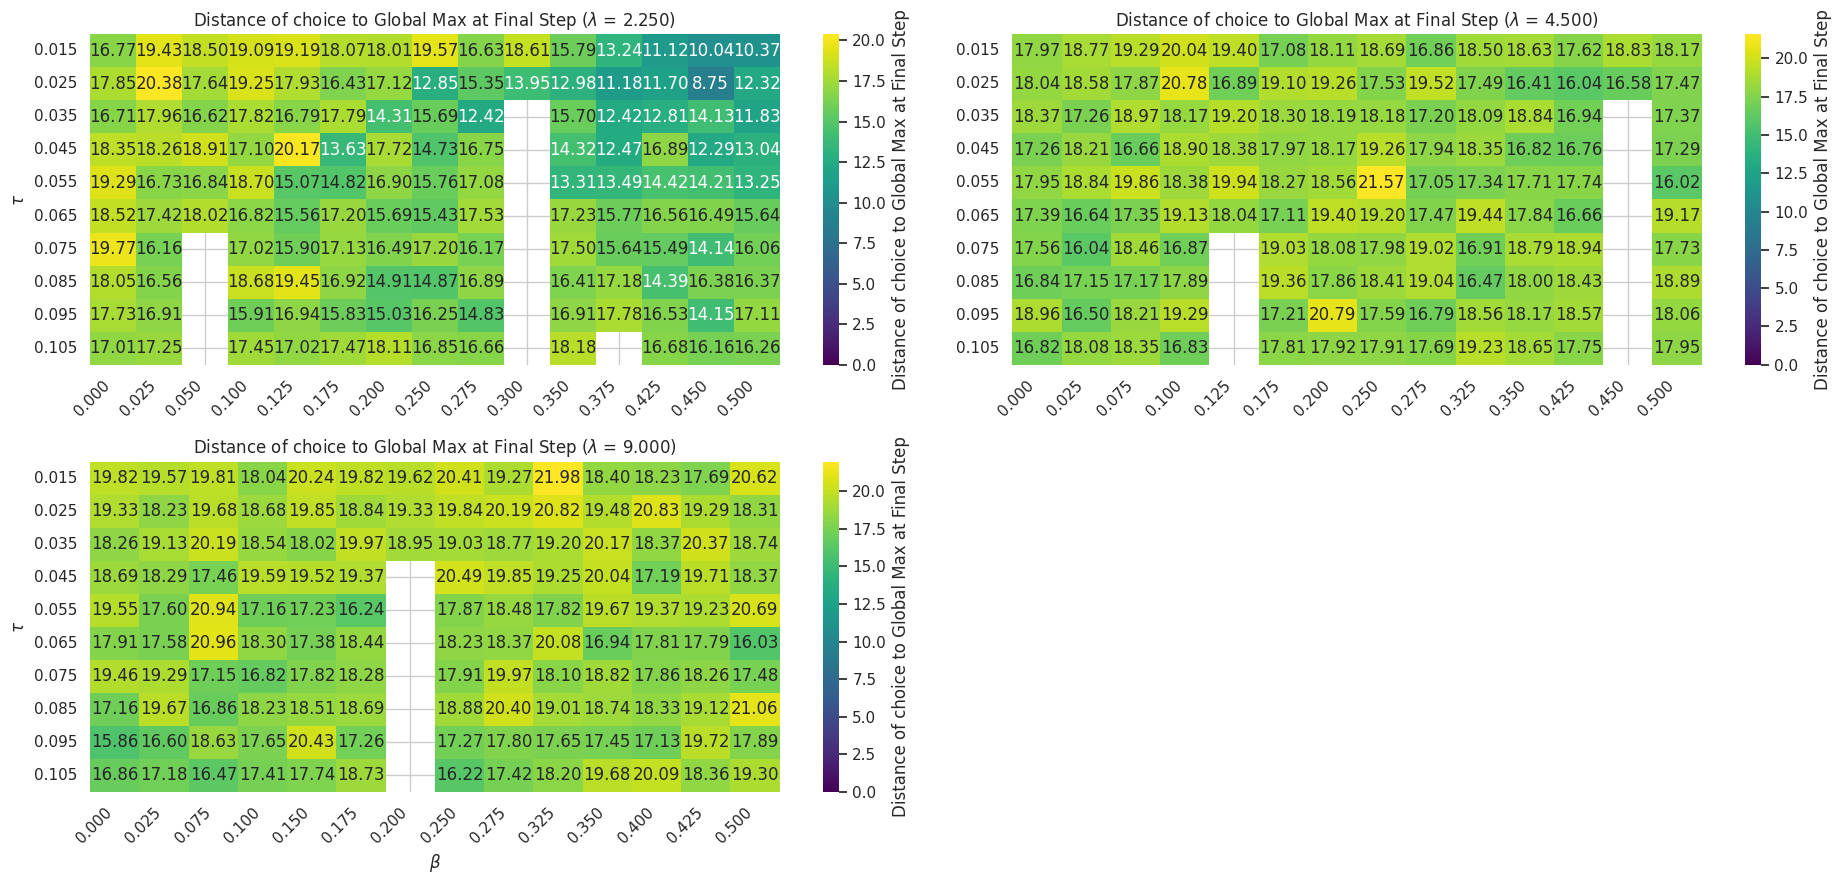

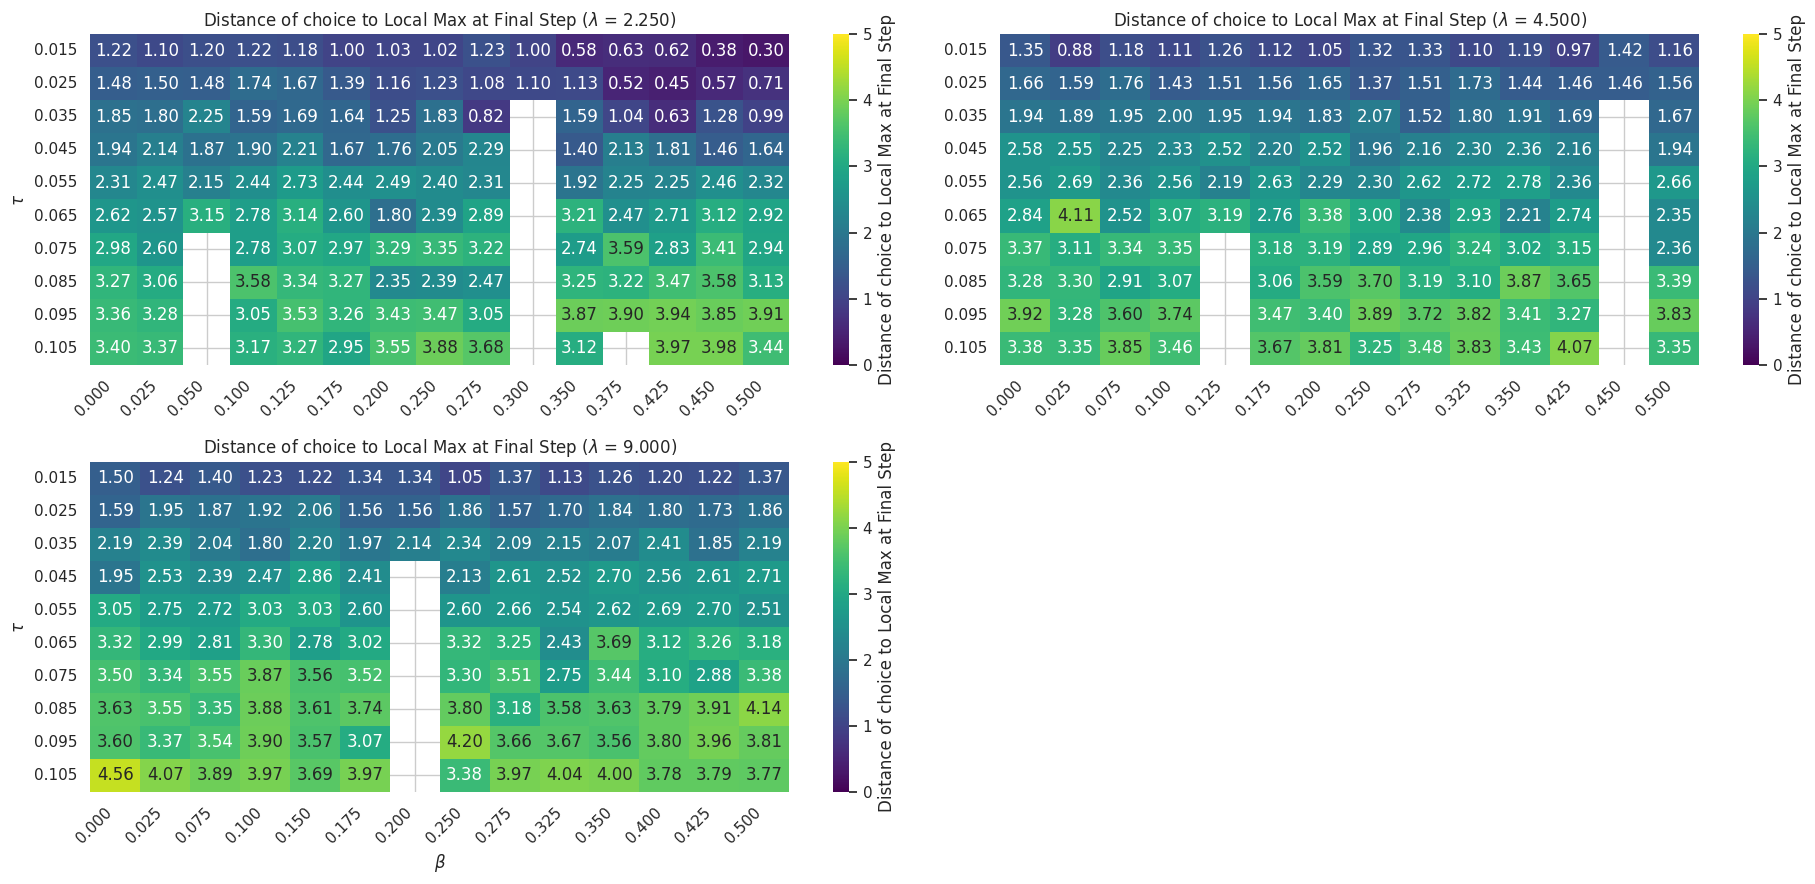

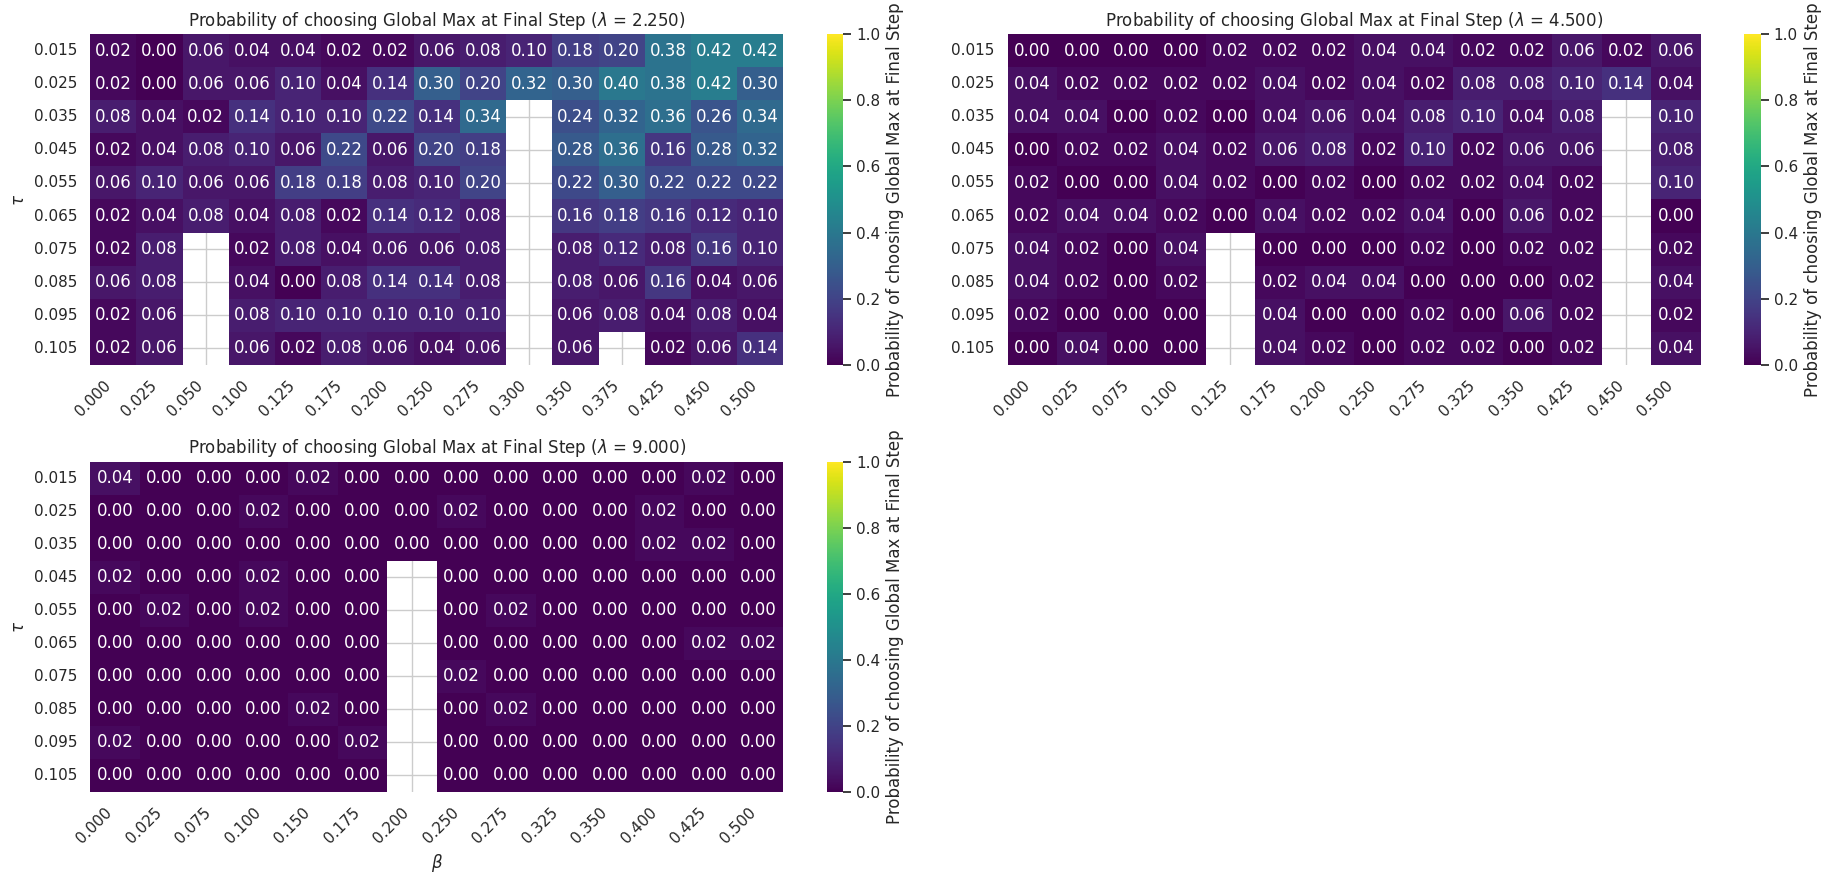

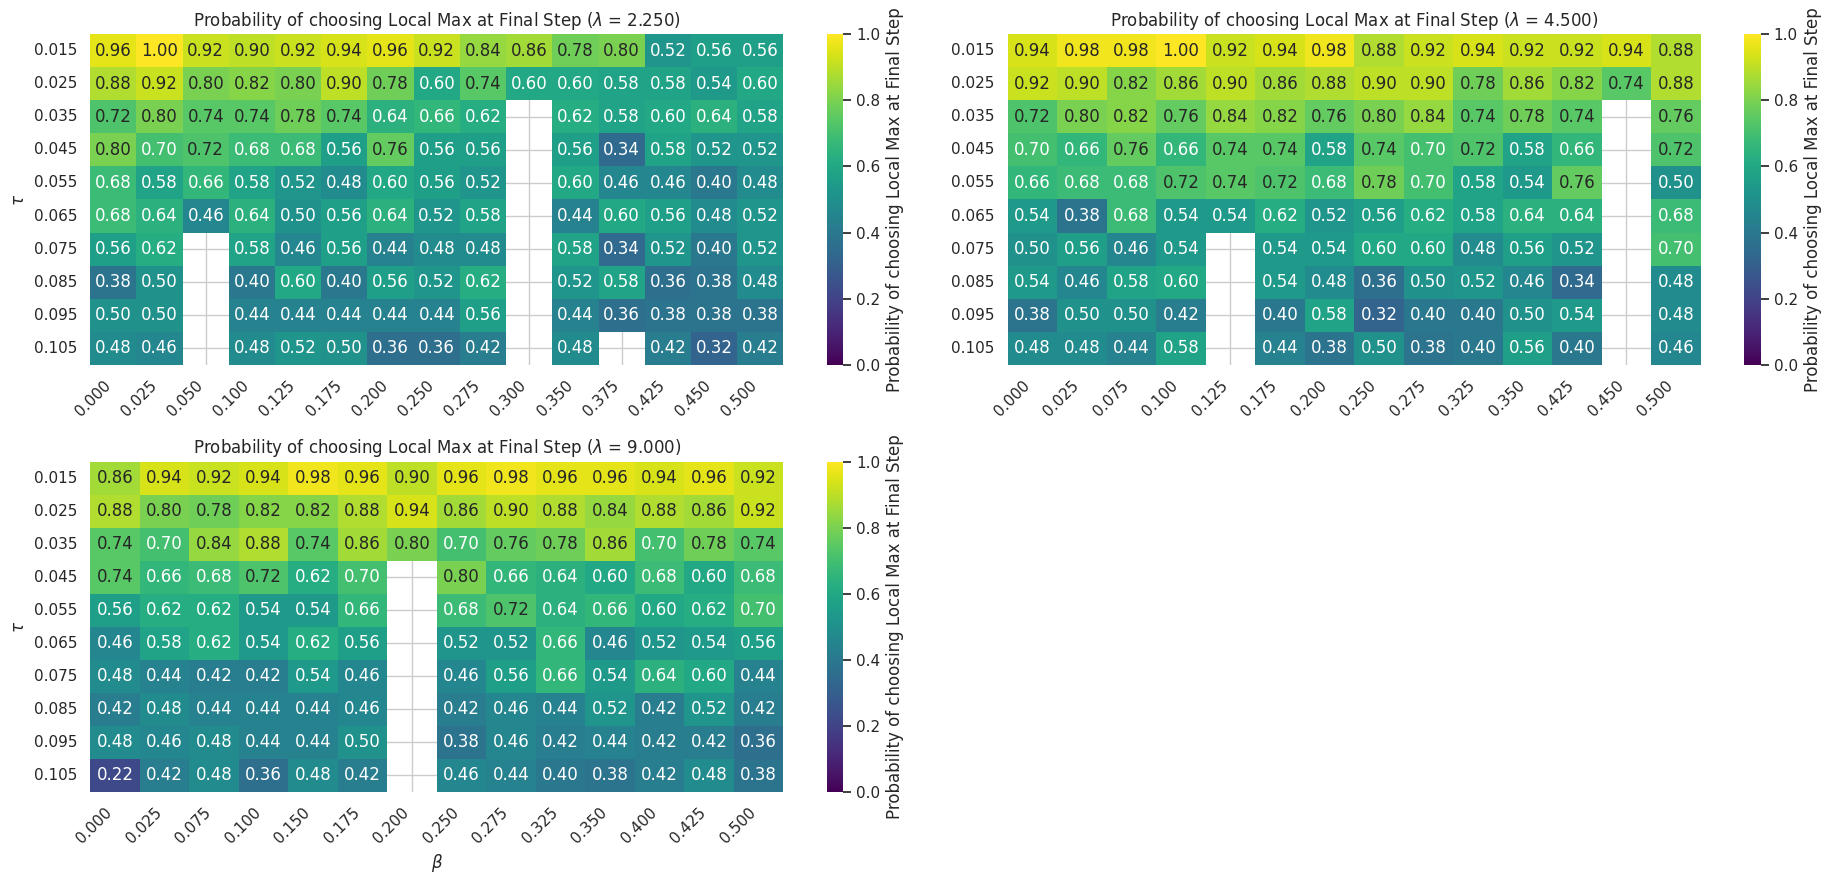

[(<Figure size 1900x900 with 7 Axes>,
  array([[<Axes: title={'center': 'Mean Reward ($\\lambda$ = 2.250)'}, ylabel='$\\tau$'>,
          <Axes: title={'center': 'Mean Reward ($\\lambda$ = 4.500)'}>],
         [<Axes: title={'center': 'Mean Reward ($\\lambda$ = 9.000)'}, xlabel='$\\beta$', ylabel='$\\tau$'>,
          <Axes: >]], dtype=object)),
 (<Figure size 1900x900 with 7 Axes>,
  array([[<Axes: title={'center': 'Mean Cumulative Reward ($\\lambda$ = 2.250)'}, ylabel='$\\tau$'>,
          <Axes: title={'center': 'Mean Cumulative Reward ($\\lambda$ = 4.500)'}>],
         [<Axes: title={'center': 'Mean Cumulative Reward ($\\lambda$ = 9.000)'}, xlabel='$\\beta$', ylabel='$\\tau$'>,
          <Axes: >]], dtype=object)),
 (<Figure size 1900x900 with 7 Axes>,
  array([[<Axes: title={'center': 'Distance of choice to Global Max at Final Step ($\\lambda$ = 2.250)'}, ylabel='$\\tau$'>,
          <Axes: title={'center': 'Distance of choice to Global Max at Final Step ($\\lambda$ = 4.500)'}>],


In [12]:
metric_specs = [
    {
        'column': 'reward',
        'label': 'Mean Reward',
        'fmt': '.2f',
        'vmin': 0.5,
        'vmax': 1.0,
    },
    {
        'column': 'mean_cumulative_reward',
        'label': 'Mean Cumulative Reward',
        'fmt': '.1f',
        'vmin': 300,
        'vmax': 450,
    },
    {
        'column': 'distance_to_global_peak',
        'label': 'Distance of choice to Global Max at Final Step',
        'fmt': '.2f',
        'vmin': 0,
        'vmax': None,
    },
    {
        'column': 'distance_to_local_peak',
        'label': 'Distance of choice to Local Max at Final Step',
        'fmt': '.2f',
        'vmin': 0,
        'vmax': 5,
    },
    {
        'column': 'global_max',
        'label': 'Probability of choosing Global Max at Final Step',
        'fmt': '.2f',
        'vmin': 0,
        'vmax': 1,
    },
    {
        'column': 'local_max',
        'label': 'Probability of choosing Local Max at Final Step',
        'fmt': '.2f',
        'vmin': 0,
        'vmax': 1,
    },
]

summary_df = summarize_batch_metrics(
    df_combined,
    metric_columns=[spec['column'] for spec in metric_specs],
    group_columns=('beta', 'length_scale', 'tau'),
)

plot_metric_suite_by_lambda(
    summary_df=summary_df,
    metric_specs=metric_specs,
    cmap='viridis',
    ncols=2,
)